In [39]:
from typing import TypedDict
class PortfolioState(TypedDict): 
    usd_amount_invested: float
    amount_in_usd: float
    amount_in_inr: float
    exchange_rate: float
def calculate_investment_returns(portfolio_state: PortfolioState) -> PortfolioState:
    portfolio_state["amount_in_usd"]=portfolio_state["usd_amount_invested"] * 1.12 
    return portfolio_state

def convert_usd_to_inr(portfolio_state: PortfolioState) -> PortfolioState:
    portfolio_state["amount_in_inr"] = portfolio_state["amount_in_usd"] * portfolio_state["exchange_rate"]
    return portfolio_state



In [40]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calculate_investment_node", calculate_investment_returns)

builder.add_node("convert_usd_to_inr_node", convert_usd_to_inr)

builder.add_edge(START, "calculate_investment_node")

builder.add_edge("calculate_investment_node","convert_usd_to_inr_node")

builder.add_edge("convert_usd_to_inr_node", END)

graph = builder.compile()

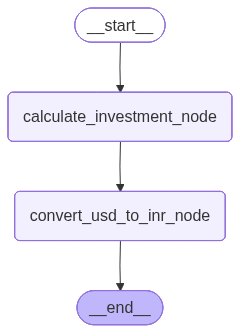

In [41]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
graph.invoke({
    "usd_amount_invested": 25000,
    "exchange_rate": 94.0,
})

{'usd_amount_invested': 25000,
 'amount_in_usd': 28000.000000000004,
 'amount_in_inr': 2632000.0000000005,
 'exchange_rate': 94.0}